In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
import sys
print(sys.executable)


e:\python practice\.venv\Scripts\python.exe


In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df["TotalCharges"].dtype

dtype('float64')

In [16]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [17]:
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [19]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [20]:
df["TotalCharges"].dtype

dtype('float64')

In [21]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [22]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [1]:
import sys 
print(sys.executable)

e:\ChurnSense\.venv\Scripts\python.exe


In [6]:
import matplotlib.pyplot as plt

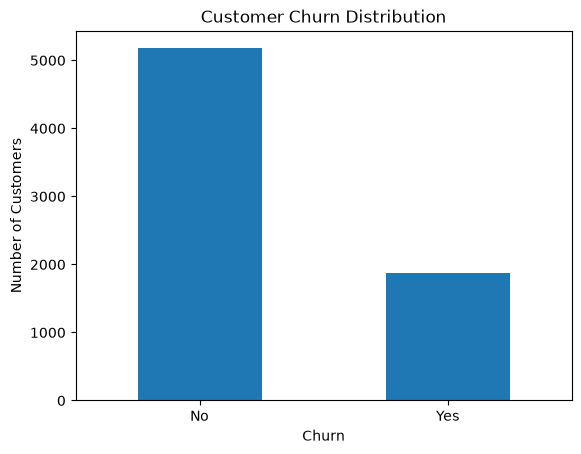

In [7]:
churn_counts = df["Churn"].value_counts()

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

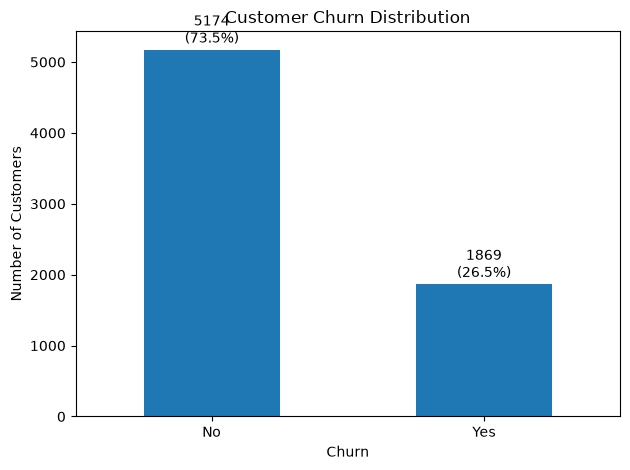

In [8]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

ax = churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for i, count in enumerate(churn_counts):
    plt.text(
        i,
        count + 100,
        f"{count}\n({churn_percent.iloc[i]:.1f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()

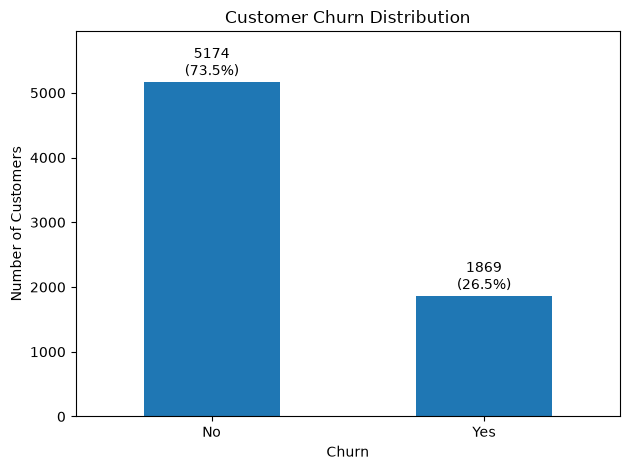

In [10]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

ax = churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Give some space above the tallest bar
plt.ylim(0, churn_counts.max() * 1.15)

for i, count in enumerate(churn_counts):
    plt.text(
        i,
        count + 100,
        f"{count}\n({churn_percent.iloc[i]:.1f}%)",
        ha="center"
    )

plt.tight_layout()
plt.savefig("../reports/churn_distribution_bar.png", dpi=300, bbox_inches="tight")
plt.show()

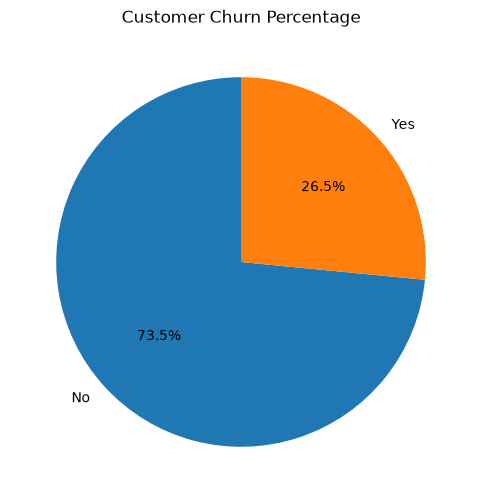

In [11]:
plt.figure(figsize=(6, 6))

churn_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.savefig(
    "../reports/churn_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


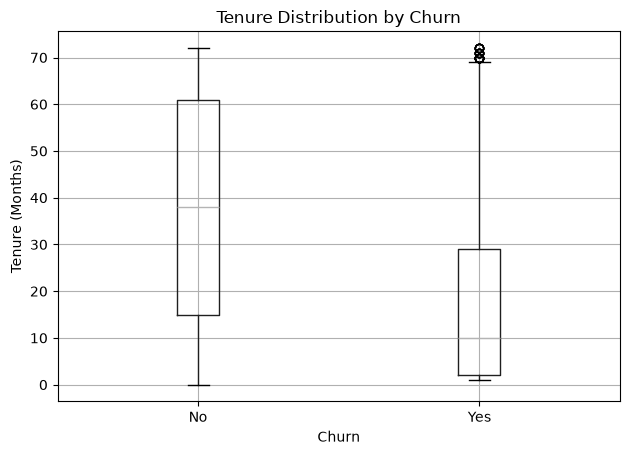

In [14]:
import matplotlib.pyplot as plt

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.savefig("../reports/tenure_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


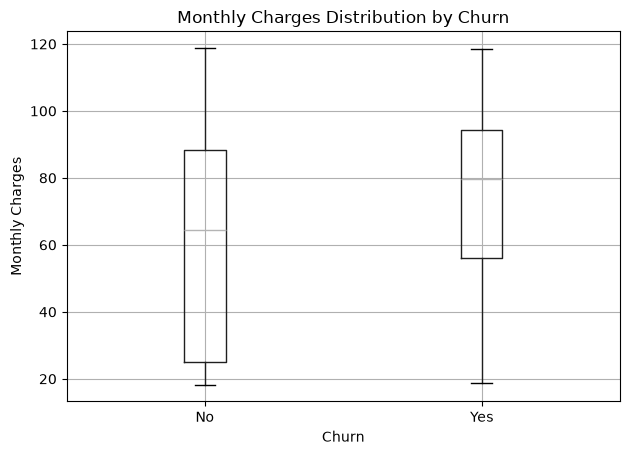

In [16]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../reports/monthly_charges_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

In [18]:
categorical_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling"
]

for column in categorical_columns:
    print("\n", column)
    print(
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )


 Contract
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

 InternetService
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

 PaymentMethod
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

 PaperlessBilling
PaperlessBilling
No     16.330084
Yes    33.565092
Name: Churn, dtype: float64


In [19]:
churn_rates = {}

for column in categorical_columns:
    churn_rates[column] = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

churn_rates

{'Contract': Contract
 Month-to-month    42.709677
 One year          11.269518
 Two year           2.831858
 Name: Churn, dtype: float64,
 'InternetService': InternetService
 DSL            18.959108
 Fiber optic    41.892765
 No              7.404980
 Name: Churn, dtype: float64,
 'PaymentMethod': PaymentMethod
 Bank transfer (automatic)    16.709845
 Credit card (automatic)      15.243101
 Electronic check             45.285412
 Mailed check                 19.106700
 Name: Churn, dtype: float64,
 'PaperlessBilling': PaperlessBilling
 No     16.330084
 Yes    33.565092
 Name: Churn, dtype: float64}

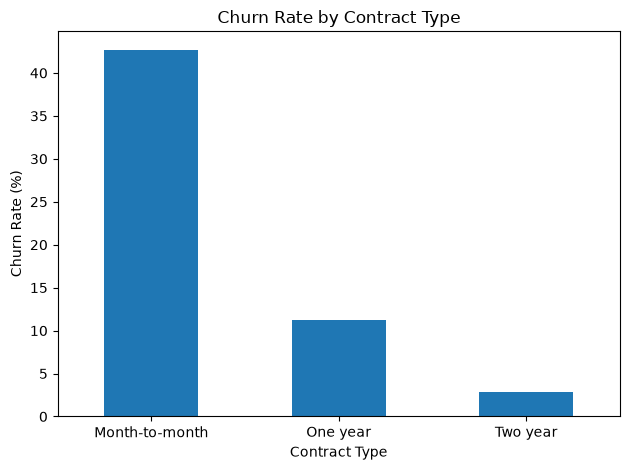

In [20]:
contract_rates = churn_rates["Contract"]

contract_rates.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../reports/churn_rate_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

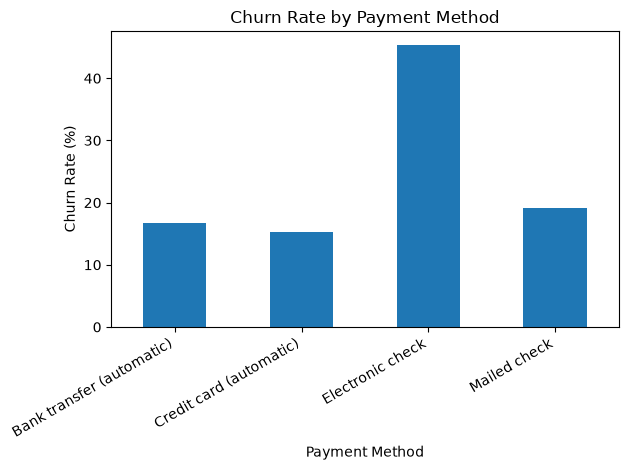

In [21]:
payment_rates = churn_rates["PaymentMethod"]

payment_rates.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    "../reports/churn_rate_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

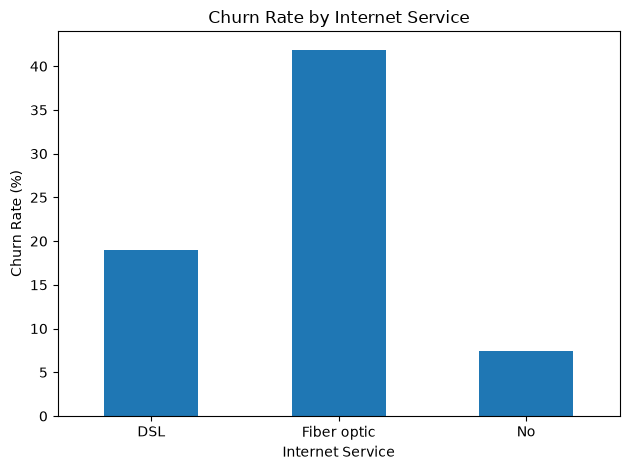

In [22]:
internet_rates = churn_rates["InternetService"]

internet_rates.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/churn_rate_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
df.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [24]:
df["Churn_numeric"] = df["Churn"].map({"No": 0, "Yes": 1})

In [25]:
df[["Churn", "Churn_numeric"]].head()

,Churn,Churn_numeric
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [26]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "Churn_numeric"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,Churn_numeric
SeniorCitizen,1.000000,0.016567,0.220173,0.150889
tenure,0.016567,1.000000,0.247900,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.193356
Churn_numeric,0.150889,-0.352229,0.193356,1.000000


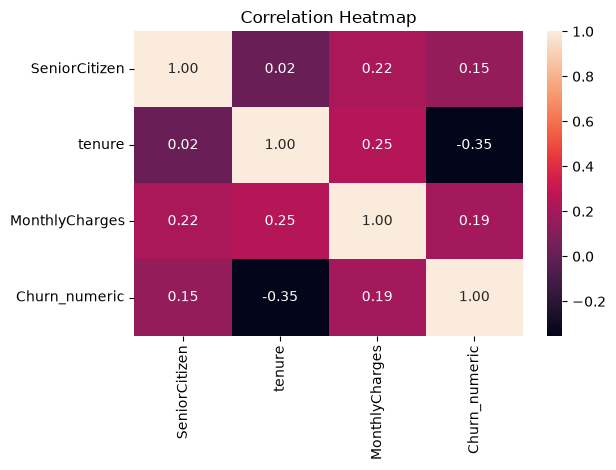

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "Churn_numeric"]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Month-to-month contracts have much higher churn — 42.7%.
Longer-tenure customers are less likely to churn — tenure has −0.35 correlation with churn.
Churned customers tend to have higher monthly charges — median ~$79.65 vs ~$64.43.
Electronic-check customers have particularly high churn — 45.3%.
Fiber-optic customers have high observed churn — 41.9%.

## Data Issues Found for Preprocessing

1. **TotalCharges has an incorrect data type.** It was initially stored as a string (`str`) even though it represents a numeric monetary value. It was converted to a numeric type.

2. **TotalCharges contains 11 missing values** after conversion to numeric. These occur for customers with zero months of tenure.

3. **Categorical columns are stored as strings**, so they will need encoding before being used in most machine learning models.

4. **Churn is a categorical target variable** (`Yes` / `No`) and will need to be encoded into numerical values for model training.

5. **The churn classes are imbalanced.** Approximately 73.5% of customers did not churn, while 26.5% churned. This should be considered when selecting evaluation metrics and training the model.